## Spotify Music Clustering Project

Music streaming platforms like Spotify generate vast amounts of data related to song characteristics, user preferences, and listening habits. Understanding patterns in this data can help in tasks such as music recommendation, playlist generation, and genre discovery. In this project you are to focus on using clustering techniques to group songs based on their audio features, uncovering hidden structures in the dataset. By analyzing these clusters, one can gain insights into different music styles and potentially enhance recommendation systems.

### 1. Load necessary libraries & Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
#load the dataset
data=pd.read_csv(r"D:\Advanced_Machine_Learning\Clustering_Algorithms\dataset\ML_spotify_data.csv")
data.head()

,name,artists,popularity,danceability,valence,energy,explicit,key,liveness,loudness,speechiness,tempo
0,We're For The Dark - Remastered 2010,['Badfinger'],22,0.678,0.559,0.432,0,3,0.0727,-12.696,0.0334,117.674
1,Sixty Years On - Piano Demo,['Elton John'],25,0.456,0.259,0.368,0,6,0.1560,-10.692,0.0280,143.783
2,Got to Find Another Way,['The Guess Who'],21,0.433,0.833,0.724,0,0,0.1700,-9.803,0.0378,84.341
3,Feelin' Alright - Live At The Fillmore East/1970,['Joe Cocker'],22,0.436,0.870,0.914,0,5,0.8550,-6.955,0.0610,174.005
4,Caravan - Take 7,['Van Morrison'],23,0.669,0.564,0.412,0,7,0.4010,-13.095,0.0679,78.716


In [3]:
#check and drop for duplicates
data[data.duplicated()]
data.drop_duplicates(inplace=True)

In [4]:
#check for missingness
data.isnull().sum()

name            0
artists         0
popularity      0
danceability    0
valence         0
energy          0
explicit        0
key             0
liveness        0
loudness        0
speechiness     0
tempo           0
dtype: int64

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9999 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          9999 non-null   object 
 1   artists       9999 non-null   object 
 2   popularity    9999 non-null   int64  
 3   danceability  9999 non-null   float64
 4   valence       9999 non-null   float64
 5   energy        9999 non-null   float64
 6   explicit      9999 non-null   int64  
 7   key           9999 non-null   int64  
 8   liveness      9999 non-null   float64
 9   loudness      9999 non-null   float64
 10  speechiness   9999 non-null   float64
 11  tempo         9999 non-null   float64
dtypes: float64(7), int64(3), object(2)
memory usage: 1015.5+ KB


Dropped all the duplicates and the data had no missingness. We can proceed to EDA, but please note, the EDA in this notebook is not the least bit extensive, the focus of this lesson was on unsupervised clustering, but please go ahead and do a full EDA of your data- extra points for that in your submission.


### 2. Exploratory Data Analysis (EDA)

In [5]:
num_df=data.select_dtypes(include=np.number)
cat_df=data.select_dtypes(exclude=np.number)

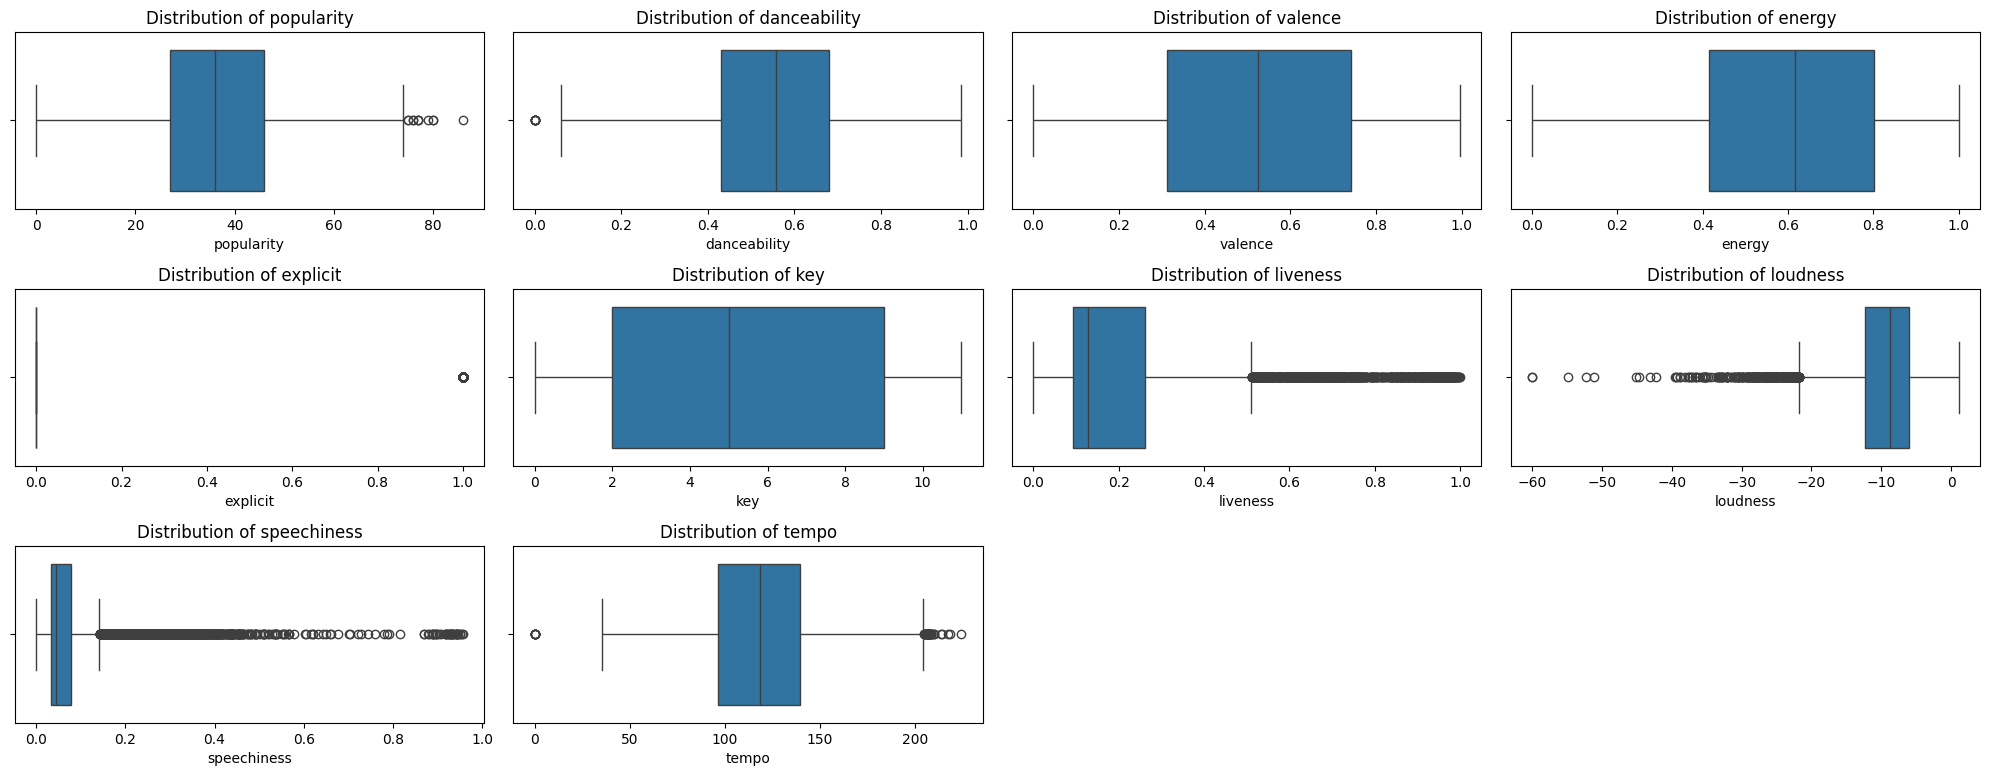

In [6]:
fig=plt.figure(figsize=(20,10))
for i in range(len(num_df.columns)):
    plt.subplot(4,4,i+1)
    sns.boxplot(x=num_df.columns[i],data=num_df)
    plt.title("Distribution of " + num_df.columns[i])
    plt.xlabel(num_df.columns[i])
plt.tight_layout()
plt.show()

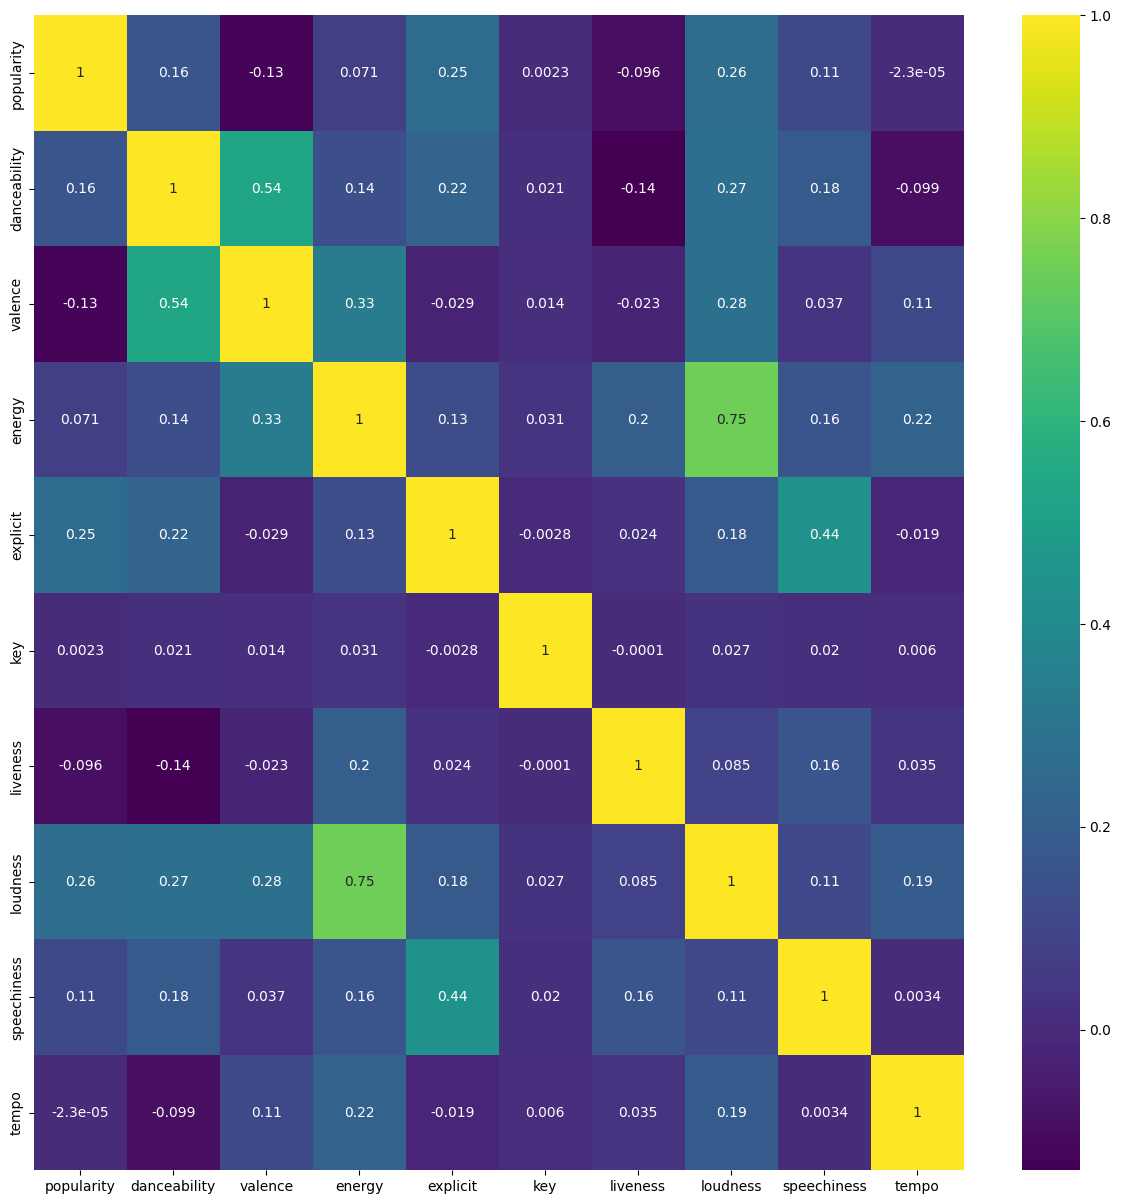

In [7]:
#correlation matrix
corrmat = num_df.corr()
top_corr_features = corrmat.index
plt.figure(figsize=(15,15))
g=sns.heatmap(num_df[top_corr_features].corr(),annot=True,cmap="viridis")

### 3. Data pre-processsing & preparation

For unsupervised clustering, scaling very important because clustering algorithms measure distance between data points (i.e K-mean clustering,DBSCAN) and if your features are on very different scales, the ones with larger numbers will dominate that distance calculation unfairly.

So always scale your features before applying any clustering algorithm

In [10]:
# feature scaling
from sklearn.preprocessing import StandardScaler, RobustScaler

df=num_df.copy()
scaler=RobustScaler()
scaled_df=scaler.fit_transform(df)
scaled_df=pd.DataFrame(scaled_df, columns=df.columns)

In [11]:
scaled_df.head()

,popularity,danceability,valence,energy,explicit,key,liveness,loudness,speechiness,tempo
0,-0.736842,0.482072,0.081585,-0.475452,0.0,-0.285714,-0.336924,-0.626792,-0.270833,-0.015062
1,-0.578947,-0.402390,-0.617716,-0.640827,0.0,0.142857,0.161580,-0.307582,-0.395833,0.586230
2,-0.789474,-0.494024,0.720280,0.279070,0.0,-0.714286,0.245362,-0.165976,-0.168981,-0.782723
3,-0.736842,-0.482072,0.806527,0.770026,0.0,0.000000,4.344704,0.287671,0.368056,1.282245
4,-0.684211,0.446215,0.093240,-0.527132,0.0,0.285714,1.627768,-0.690347,0.527778,-0.912267


### 4. Clustering Algorithms

First I start with hierarchical clustering, because it can help me identify any natural clusters more easily, then I can fit that into my K-means, GMM etc...

The dendogram is supposed to give us a rough idea of the ideal k: We look for the longest vertical line that isn't crossed by a horizontal line- that gap suggests a natural number of clusters

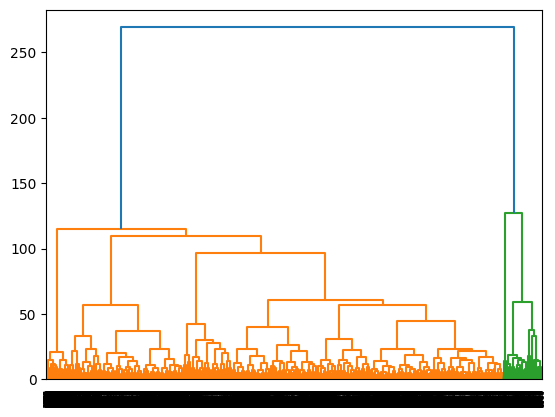

In [12]:
#start with hierarchical clustering- just to identify the number of clusters, roughly
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

wards_clustering = linkage(scaled_df, method="ward")
dendrogram(wards_clustering)
plt.show()

From my interpretation, there are only 2 longest vertical lines not crossed by any horizontal line. So I am going to fit my K-means using k=2 as my baseline model


NOTE: Please note, for hierarchical clustering, because I am just using it to give me an idea of a good value of clusters for my other clustering algorithms I used a simple library called scipy, please run ```pip install scipy``` on your terminal to get started with it. Why did I use it? because the library has a native way of plotting dendograms- which is what I want, so that I can see any natural groupings in my data.

In short, plotting the dendogram with the ```scipy``` library is more simple- so let's take advantage of that.

In [13]:
#apply K-means clustering
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=0,init='k-means++',n_init="auto").fit(scaled_df)

labels = kmeans.labels_
centroids = kmeans.cluster_centers_


print(centroids)
print("\nCluster Labels for Data Points:")
print(labels)

[[ 0.05209138 -0.07842802 -0.01047928 -0.0821334   0.05871317  0.02639255
   0.45353063 -0.20061875  0.22935852  0.04472146]
 [ 0.37094602  0.43917932  0.07956223  0.14863083  0.53304904  0.05863539
   0.76829688  0.13568348  6.74936824  0.02250592]]

Cluster Labels for Data Points:
[0 0 0 ... 0 1 0]


##### Use silhouette score to evaluate clustering algorithms

The Silhouette Score measures how well each data point fits within its assigned cluster and how well-separated it is from other clusters. It is actually a combination of 2 metrics:
* Intra-cluster distance- This is the average distance between the data point and all other points in the same cluster. A smaller value indicates the point is closely aligned with its cluster.
* Nearest-cluster distance- This is the average distance between the data point and all points in the nearest neighbouring cluster (the next best alternative). A larger value means the point is well-separated from other clusters.

It ranges from -1 to 1, a higher value is better!

In [14]:
from sklearn.metrics import silhouette_score
silhouette_score(scaled_df, kmeans.labels_, metric='euclidean')

0.5594680445529171

##### Finding the right value for k

To find the optimum value for K, we use the elbow method. We plot a graph of inertia (Within Cluster Sum of Squares) against different values of k.


##### What is inertia?
Inertia measures the compactness or internal coherence of clusters. It calculates the sum of squared Euclidean distances between each data point and its nearest cluster center (centroid). Lower inertia indicates tighter, more dense clusters, making it the primary objective metric minimized by centroid-based algorithms like K-Means.

Though not a total must, we could also use a plot of the silhoutte score at different values of k to give us an optimum k, but this you can do without.But can be good to validate the k you identify from the elbow method.

In [18]:
inertias = []
sil_scores = []
k_range = range(2, 15)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=0,init='k-means++',n_init="auto").fit(scaled_df)
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(scaled_df, kmeans.labels_))

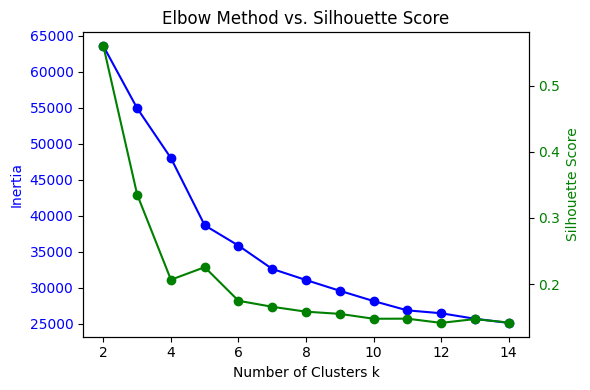

In [19]:
fig, ax1 = plt.subplots(figsize=(6, 4))

# Inertia (Elbow Method)
ax1.plot(k_range, inertias, 'bo-', label='Inertia (Elbow)')
ax1.set_xlabel('Number of Clusters k')
ax1.set_ylabel('Inertia', color='b')
ax1.tick_params(axis='y', labelcolor='b')

#Silhouette Score
ax2 = ax1.twinx()
ax2.plot(k_range, sil_scores, 'go-', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='g')
ax2.tick_params(axis='y', labelcolor='g')

plt.title('Elbow Method vs. Silhouette Score')
fig.tight_layout()
plt.show()

So from the plot above, the bets value of k is that which minimizes the inertia and that which maximises the silhouette score. From the graph, I see that is 5... its also the value at the 'elbow' of the graph

In [20]:
kmeans_final = KMeans(n_clusters=5, random_state=42, 
                      init='k-means++', n_init='auto')
kmeans_final.fit(scaled_df)
labels_kmeans = kmeans_final.labels_

In [21]:
from sklearn.metrics import silhouette_score
silhouette_score(scaled_df, kmeans_final.labels_, metric='euclidean')

0.22550862542844632

##### Why do I choose 5 clusters, even though it gives me a lower silhouette score?

Its more meaningful to have 5 segments than 2, from a business perspective.

#### Visualizing the results of the K-means
Apart from the silhouette score, another way of interpretting the results of your clustering algorithm is through visualization of the clusters. But, since we are limited to a 2D canvas, we have to do dimensionality reduction first, then cluster the reduced features.

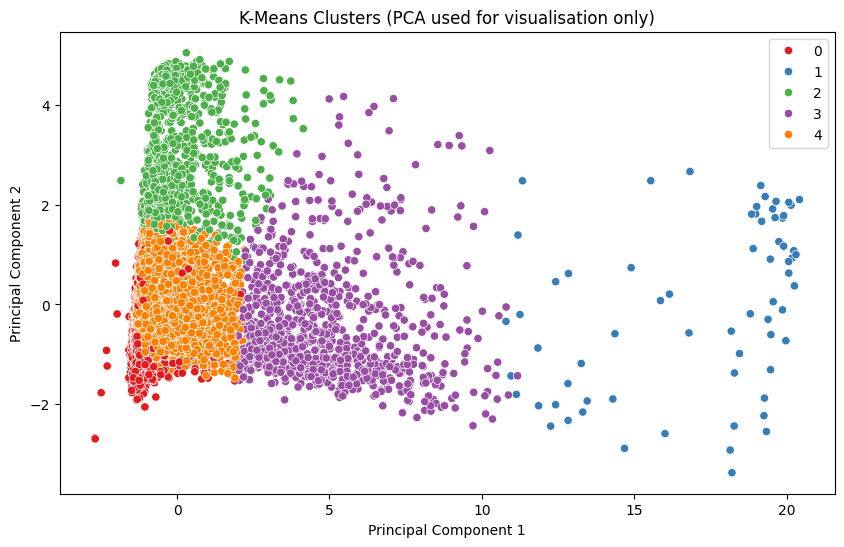

In [24]:
# cluster on the full data, but visualise using PCA only
kmeans_final = KMeans(n_clusters=5, random_state=42, init='k-means++', n_init='auto')
labels_kmeans = kmeans_final.fit_predict(scaled_df)

# reduce to 2D for visualisation only
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_df)

# plot your graph
plt.figure(figsize=(10, 6))
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=labels_kmeans, palette='Set1')
plt.title('K-Means Clusters (PCA used for visualisation only)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

#### Gaussian Mixture Methods

Apply GMM, optimize for n_components, compare silhouette scores with Kmeans and then visualize using reduced data.

In [25]:
#apply gaussian mixture model
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=5,covariance_type='full', random_state=42)

# Fit the model
gmm.fit(scaled_df)

# Get cluster labels and probabilities
labels = gmm.predict(scaled_df)
probs = gmm.predict_proba(scaled_df)

In [26]:
#report silhouette score for GMM
silhouette_score(scaled_df, labels, metric='euclidean')

0.03296461234920501

Looks like K-means outperforms GMM, let's optimize for the number of gaussian components and see if that makes a difference.

##### Optimizing for the number of gaussian components

In Gaussian Mixture Models (GMM), we use AIC (Akaike Information Criterion) and BIC (Bayesian Information Criterion) to identify the optimal number of gaussian components. AIC and BIC  are mathematical metrics used to determine the optimal number of clusters or components (k). They balance model accuracy (log-likelihood) with complexity to prevent overfitting.

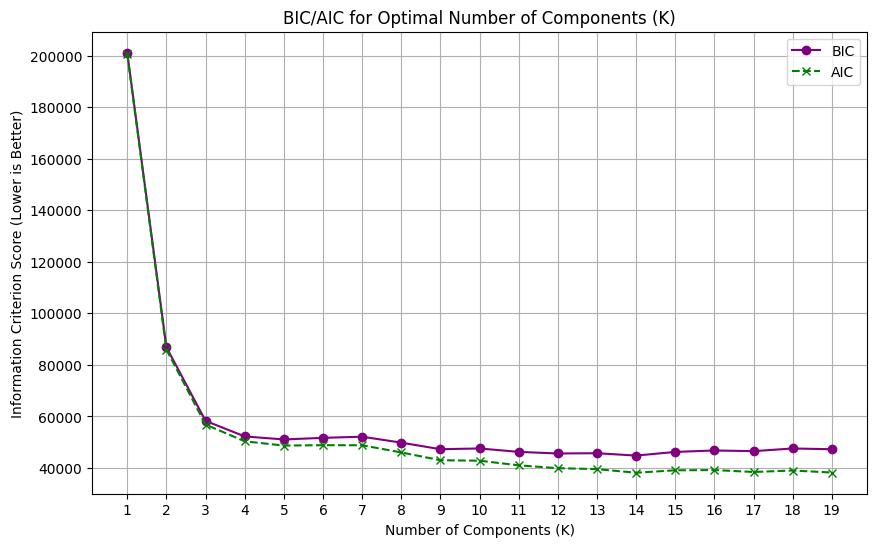

In [27]:
k_range = range(1, 20)
bic = []
aic = []


for k in k_range:
    gmm = GaussianMixture(n_components=k,covariance_type='full', random_state=42)
    gmm.fit(scaled_df)
    
    bic.append(gmm.bic(scaled_df))
    aic.append(gmm.aic(scaled_df))

# Plot the BIC and AIC scores
plt.figure(figsize=(10, 6))
plt.plot(k_range, bic, marker='o', linestyle='-', color='purple', label='BIC')
plt.plot(k_range, aic, marker='x', linestyle='--', color='green', label='AIC')
plt.title('BIC/AIC for Optimal Number of Components (K)')
plt.xlabel('Number of Components (K)')
plt.ylabel('Information Criterion Score (Lower is Better)')
plt.xticks(k_range)
plt.legend()
plt.grid(True)

plt.show()

From the plot above- I will go with 3 gaussian components.

In [28]:
gmm_final = GaussianMixture(n_components=3,covariance_type='full', random_state=42)
gmm_final.fit(scaled_df)
labels_gmm = gmm_final.predict(scaled_df)

#report silhouette score for GMM
silhouette_score(scaled_df, labels_gmm, metric='euclidean')

0.19122410398394643

#### Visualizing the Results of GMM

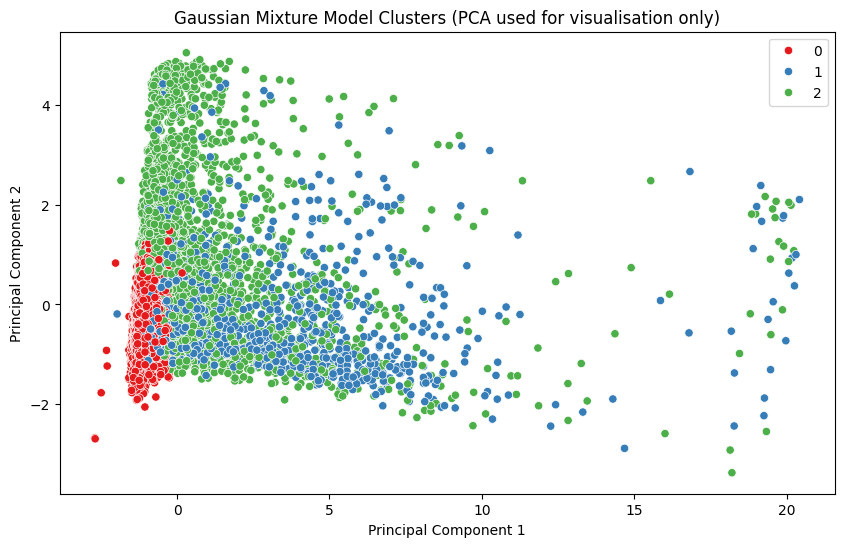

In [29]:
# cluster on the full data, but visualise using PCA only
gmm_final = GaussianMixture(n_components=3,covariance_type='full', random_state=42)
gmm_final.fit(scaled_df)
labels_gmm = gmm_final.predict(scaled_df)


# reduce to 2D for visualisation only
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_df)

# plot your graph
plt.figure(figsize=(10, 6))
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=labels_gmm, palette='Set1')
plt.title('Gaussian Mixture Model Clusters (PCA used for visualisation only)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

As you can see from the visualization, GMM still has a lot of overlap in its clusters, and this is validated by the lower silhouette scores compared to K-Means

Let's fit a DBSCAN algorithms and see...


#### DBSCAN

When it comes to DBSCAN, remember from the previous class we learned that there are 2 main parameters, first epsilon which is the radius of our neighbourhood and Minpoints- which is minimum number of points that define a cluster.
So the first step in DBSCAN is choosing the right epsilon- we use what is called a k-distance plot to find the epsilon.

All the k-distance plot does is for every point in your dataset,it find its k nearest neighbors and records the distance to the furthest one, then it sorts all those distances from largest to smallest and plots them.

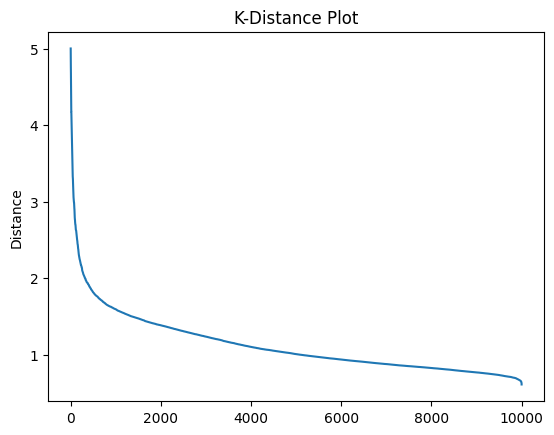

In [34]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

min_samples = max(2 * scaled_df.shape[1], 5)
nbrs = NearestNeighbors(n_neighbors=min_samples).fit(scaled_df)
distances, _ = nbrs.kneighbors(scaled_df)

plt.plot(np.sort(distances[:, -1])[::-1])
plt.title("K-Distance Plot")
plt.ylabel("Distance")
plt.show()

From the k-distance , the best value for epsilon is approx. 1.8

In [46]:
#apply dbscan clustering
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=min_samples)
labels_dbscan = dbscan.fit_predict(pca_result)
n_noise = (labels == -1).sum()


print(f"\nNoise points (label=-1): {(labels_dbscan == -1).sum()}")
print(f"% noise: {n_noise / len(labels_dbscan) * 100:.1f}%")
print(f"Number of clusters found: {len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)}")
print(f"Cluster labels: {sorted(set(labels_dbscan))}")


Noise points (label=-1): 37
% noise: 0.0%
Number of clusters found: 2
Cluster labels: [np.int64(-1), np.int64(0), np.int64(1)]


DBSCAN founds 2 distinct clusters on the reduced data, lets report the silhouette score and see how it performs against the others...

In [44]:
from sklearn.metrics import silhouette_score

# exclude noise points (label = -1)
mask = labels_dbscan != -1
score = silhouette_score(pca_result[mask], labels_dbscan[mask])
print(f"Silhouette Score: {score:.3f}")

Silhouette Score: 0.875


Yaaaay! The silhouette score is better than K-means(0.22) and GMM(0.19)... 

##### Visualizing the DBSCAN clusters

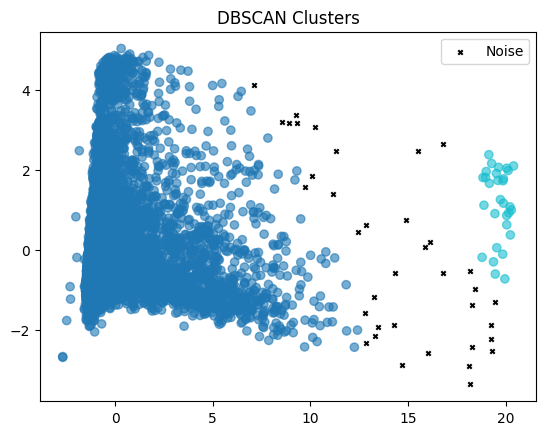

In [45]:
mask = labels_dbscan != -1

plt.scatter(pca_result[mask, 0], pca_result[mask, 1], c=labels_dbscan[mask], cmap='tab10', alpha=0.6)
plt.scatter(pca_result[~mask, 0], pca_result[~mask, 1], c='black', marker='x', s=10, label='Noise')
plt.legend()
plt.title("DBSCAN Clusters")
plt.show()

DBSCAN gives us 2 clusters with a veru high silhoutte score of 0.875

### Cluster Analysis